
# HPO Analysis

This notebook summarizes the refined HPO pipeline using the canonical exports in `results/hpo/hpo_summary.csv` and `results/hpo/hpo_winners.csv`.

The notebook deliberately ignores the legacy stage-1 / stage-2 folder layout and instead analyzes the refined workflow stages `smoke`, `policy`, and `refine`.


## 1. Imports

In [10]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.precision', 6)


## 2. Reading In The Data

In [11]:

REPO_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
HPO_ROOT = None
for candidate in REPO_CANDIDATES:
    direct = candidate / 'results' / 'hpo'
    if (direct / 'hpo_summary.csv').exists() and (direct / 'hpo_winners.csv').exists():
        HPO_ROOT = direct
        break
    if (candidate / 'hpo_summary.csv').exists() and (candidate / 'hpo_winners.csv').exists():
        HPO_ROOT = candidate
        break
if HPO_ROOT is None:
    raise FileNotFoundError('Could not locate results/hpo with hpo_summary.csv and hpo_winners.csv')

SUMMARY_PATH = HPO_ROOT / 'hpo_summary.csv'
WINNERS_PATH = HPO_ROOT / 'hpo_winners.csv'

METHOD_LABELS = {
    'qbc_deep_ensemble': 'QBC Deep Ensemble',
    'marker_directed': 'Marker-Directed',
    'qbc_marker_hybrid': 'QBC Marker Hybrid',
}
MODEL_LABELS = {
    'SM4': 'SM4',
    'SM6': 'SM6',
    'SM_AVR_GOV': 'SM9',
}
STAGE_LABELS = {
    'smoke': 'Smoke',
    'policy': 'Policy',
    'refine': 'Refine',
}
LEGACY_STAGE_MAP = {
    'stage0_smoke': 'smoke',
    'stageA_policy': 'policy',
    'stageB_refine': 'refine',
}
ADAPTIVE_METHODS = list(METHOD_LABELS)
STAGE_ORDER = ['smoke', 'policy', 'refine']
MODEL_ORDER = ['SM4', 'SM6', 'SM_AVR_GOV']

summary_raw = pd.read_csv(SUMMARY_PATH)
winners_raw = pd.read_csv(WINNERS_PATH)

def filter_refined(df: pd.DataFrame) -> pd.DataFrame:
    workflow_id = df['workflow_id'].astype(str)
    mask = workflow_id.str.endswith('_v1')
    mask &= ~workflow_id.str.contains('localcheck|plumbingcheck', case=False, na=False)
    mask &= df['method'].isin(ADAPTIVE_METHODS)
    return df.loc[mask].copy()

def normalize_stage(stage_value: str) -> str:
    stage = str(stage_value)
    return LEGACY_STAGE_MAP.get(stage, stage)

summary = filter_refined(summary_raw)
winners = filter_refined(winners_raw)

summary['stage'] = summary['stage'].map(normalize_stage)
winners['stage'] = winners['stage'].map(normalize_stage)
summary = (
    summary[summary['stage'].isin(STAGE_ORDER)]
    .drop_duplicates(['workflow_id', 'method', 'model_flag', 'stage', 'cfg_id', 'dataset_seed', 'budget'])
    .copy()
)
winners = (
    winners[winners['stage'].isin(STAGE_ORDER)]
    .sort_values(['workflow_id', 'method', 'model_flag', 'stage'])
    .drop_duplicates(['workflow_id', 'method', 'model_flag', 'stage'])
    .copy()
)

for df in [summary, winners]:
    df['method_label'] = df['method'].map(METHOD_LABELS)
    df['model_label'] = df['model_flag'].map(MODEL_LABELS)
    df['stage_label'] = df['stage'].map(STAGE_LABELS)
    df['stage'] = pd.Categorical(df['stage'], categories=STAGE_ORDER, ordered=True)
    df['model_flag'] = pd.Categorical(df['model_flag'], categories=MODEL_ORDER, ordered=True)

print('HPO_ROOT:', HPO_ROOT)
print('summary_raw rows:', len(summary_raw))
print('winners_raw rows:', len(winners_raw))
print('refined summary rows:', len(summary))
print('refined winners rows:', len(winners))


HPO_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/hpo
summary_raw rows: 1370
winners_raw rows: 32
refined summary rows: 1347
refined winners rows: 26


## 3. Refined Workflow Structure

In [12]:

workflow_overview = (
    summary.groupby(['model_label', 'method_label', 'stage'], observed=True)
    .agg(
        n_rows=('cfg_id', 'size'),
        n_configs=('cfg_id', 'nunique'),
        n_config_groups=('config_group_id', 'nunique'),
        n_dataset_seeds=('dataset_seed', 'nunique'),
        budgets=('budget', lambda s: ', '.join(sorted({str(v) for v in s.dropna()}))),
        mean_final_eval_rmse=('final_eval_rmse', 'mean'),
        median_final_round_seconds=('final_round_seconds', 'median'),
        median_final_train_seconds=('final_train_seconds', 'median'),
    )
    .reset_index()
)

display(workflow_overview)

structure_summary = pd.DataFrame({
    'n_models': [summary['model_flag'].nunique()],
    'n_methods': [summary['method'].nunique()],
    'n_workflows': [summary['workflow_id'].nunique()],
    'n_stages_present': [summary['stage'].nunique()],
    'n_candidate_rows': [len(summary)],
    'n_winner_rows': [len(winners)],
    'n_unique_cfg_ids': [summary['cfg_id'].nunique()],
    'n_unique_cfg_groups': [summary['config_group_id'].nunique()],
})
display(structure_summary)


,model_label,method_label,stage,n_rows,n_configs,n_config_groups,n_dataset_seeds,budgets,mean_final_eval_rmse,median_final_round_seconds,median_final_train_seconds
0,SM4,Marker-Directed,smoke,1,1,1,1,b256,NaN,0.591816,0.000000
1,SM4,Marker-Directed,policy,144,144,48,3,b1024,0.007910,23.439216,18.811505
2,SM4,Marker-Directed,refine,216,216,72,3,b4096,0.003460,84.017547,73.281750
3,SM4,QBC Deep Ensemble,smoke,1,1,1,1,b256,0.020694,11.056644,10.958791
4,SM4,QBC Deep Ensemble,policy,72,72,24,3,b1024,0.006823,24.994036,24.208932
5,SM4,QBC Deep Ensemble,refine,162,162,54,3,b4096,0.003039,121.836620,120.161623
6,SM4,QBC Marker Hybrid,smoke,1,1,1,1,b256,0.019856,8.298655,7.698574
7,SM4,QBC Marker Hybrid,policy,144,144,48,3,b1024,0.006629,31.704492,29.737398
8,SM4,QBC Marker Hybrid,refine,144,144,48,3,b4096,0.002936,127.827451,122.535660
9,SM6,Marker-Directed,smoke,1,1,1,1,b256,NaN,0.884076,0.000000


,n_models,n_methods,n_workflows,n_stages_present,n_candidate_rows,n_winner_rows,n_unique_cfg_ids,n_unique_cfg_groups
0,3,3,9,3,1347,26,1145,320


## 4. Winner Summaries Per Model

In [13]:

preferred_stage_order = {'refine': 2, 'policy': 1, 'smoke': 0}

winner_stage_table = (
    winners[['model_label', 'method_label', 'stage', 'objective_mean', 'objective_std', 'n_dataset_seeds', 'shortlist_size']]
    .assign(stage=lambda d: d['stage'].astype(str))
)

final_winners = (
    winners.assign(stage_rank=lambda d: d['stage'].astype(str).map(preferred_stage_order))
    .sort_values(['model_flag', 'method', 'stage_rank'], ascending=[True, True, False])
    .drop_duplicates(['model_flag', 'method'])
    .copy()
)

for model_flag in MODEL_ORDER:
    model_label = MODEL_LABELS[model_flag]
    display(Markdown(f'### {model_label}'))
    stage_pivot = (
        winner_stage_table[winner_stage_table['model_label'] == model_label]
        .pivot(index='method_label', columns='stage', values='objective_mean')
        .rename(columns=lambda c: f'{c}_objective_mean')
    )
    stage_std = (
        winner_stage_table[winner_stage_table['model_label'] == model_label]
        .pivot(index='method_label', columns='stage', values='objective_std')
        .rename(columns=lambda c: f'{c}_objective_std')
    )
    final_stage = (
        final_winners[final_winners['model_label'] == model_label][['method_label', 'stage', 'objective_mean', 'objective_std', 'n_dataset_seeds', 'shortlist_size']]
        .rename(columns={
            'stage': 'selected_stage',
            'objective_mean': 'selected_objective_mean',
            'objective_std': 'selected_objective_std',
            'n_dataset_seeds': 'selected_n_dataset_seeds',
            'shortlist_size': 'selected_shortlist_size',
        })
        .assign(selected_stage=lambda d: d['selected_stage'].map(STAGE_LABELS))
        .set_index('method_label')
    )
    model_table = pd.concat([stage_pivot, stage_std, final_stage], axis=1).reset_index()
    display(model_table)


### SM4

,method_label,policy_objective_mean,refine_objective_mean,smoke_objective_mean,policy_objective_std,refine_objective_std,smoke_objective_std,selected_stage,selected_objective_mean,selected_objective_std,selected_n_dataset_seeds,selected_shortlist_size
0,Marker-Directed,0.007183,0.002828,1.0,0.000140,0.000489,0.0,Refine,0.002828,0.000489,3,3
1,QBC Deep Ensemble,0.005748,0.002189,1.0,0.000387,0.000165,0.0,Refine,0.002189,0.000165,3,3
2,QBC Marker Hybrid,0.005869,0.002336,1.0,0.000166,0.000047,0.0,Refine,0.002336,0.000047,3,3


### SM6

,method_label,policy_objective_mean,refine_objective_mean,smoke_objective_mean,policy_objective_std,refine_objective_std,smoke_objective_std,selected_stage,selected_objective_mean,selected_objective_std,selected_n_dataset_seeds,selected_shortlist_size
0,Marker-Directed,0.006345,0.002449,1.0,0.000064,0.000080,0.0,Refine,0.002449,0.000080,2,2
1,QBC Deep Ensemble,0.005655,NaN,1.0,0.000055,NaN,0.0,Policy,0.005655,0.000055,2,2
2,QBC Marker Hybrid,0.005517,0.002145,1.0,0.000493,0.000069,0.0,Refine,0.002145,0.000069,2,2


### SM9

,method_label,policy_objective_mean,refine_objective_mean,smoke_objective_mean,policy_objective_std,refine_objective_std,smoke_objective_std,selected_stage,selected_objective_mean,selected_objective_std,selected_n_dataset_seeds,selected_shortlist_size
0,Marker-Directed,0.045736,0.005642,1.0,0.000379,0.000116,0.0,Refine,0.005642,0.000116,2,2
1,QBC Deep Ensemble,0.045988,0.005263,1.0,0.000014,0.000274,0.0,Refine,0.005263,0.000274,2,2
2,QBC Marker Hybrid,0.041558,0.005471,1.0,0.008679,0.000298,0.0,Refine,0.005471,0.000298,2,2


## 5. Winner Objective Across Refined Stages

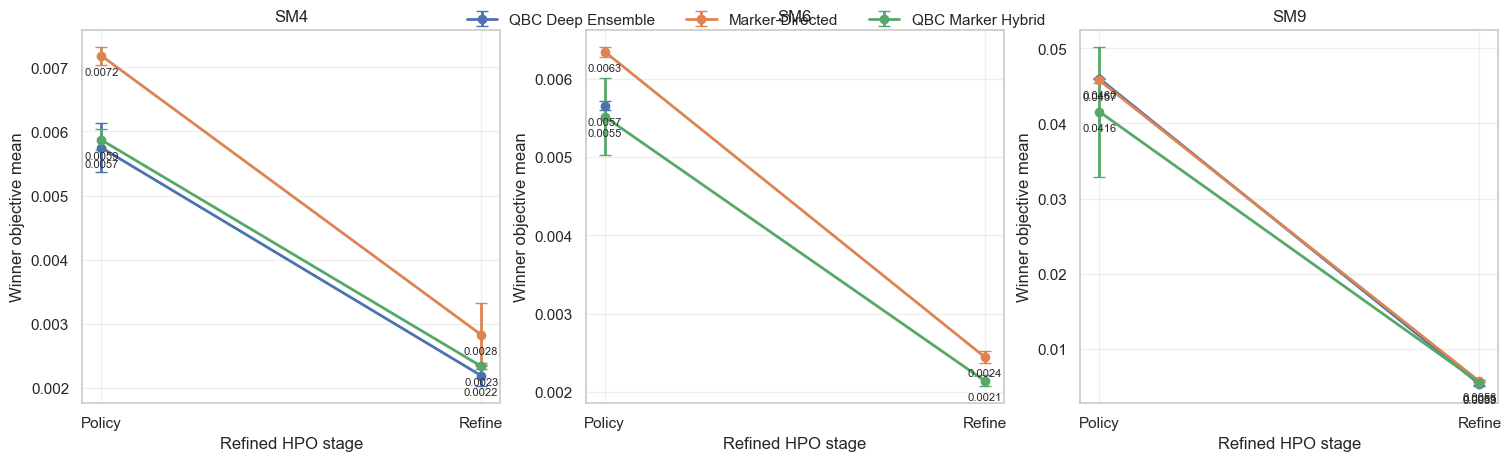

In [14]:

plot_df = winners[winners['stage'].isin(['policy', 'refine'])].copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True, sharey=False)
axes = np.atleast_1d(axes)

for ax, model_flag in zip(axes, MODEL_ORDER):
    sub = plot_df[plot_df['model_flag'].astype(str) == model_flag].copy()
    for method in ADAPTIVE_METHODS:
        method_sub = sub[sub['method'] == method].sort_values('stage')
        if method_sub.empty:
            continue
        x = [STAGE_LABELS[str(stage)] for stage in method_sub['stage'].astype(str)]
        y = method_sub['objective_mean'].to_numpy(dtype=float)
        yerr = method_sub['objective_std'].fillna(0.0).to_numpy(dtype=float)
        ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2, capsize=4, label=METHOD_LABELS[method])
        for xi, yi in zip(x, y):
            ax.annotate(f'{yi:.4f}', (xi, yi), textcoords='offset points', xytext=(0, -14), ha='center', fontsize=8)
    ax.set_title(MODEL_LABELS[model_flag])
    ax.set_ylabel('Winner objective mean')
    ax.set_xlabel('Refined HPO stage')
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
plt.show()


## 6. Final Selected Hyperparameters

In [15]:

parameter_columns = [
    'qbc_M',
    'qbc_P',
    'active.disagreement.metric',
    'active.diversity.preselect_factor',
    'active.diversity.uncertainty_weight',
    'active.diversity.distance_weight',
    'active.marker.pca_explained_variance',
    'active.marker.k_density',
    'active.marker.preselect_factor',
    'active.marker.greedy_score_weight',
    'active.marker.weights.diversity',
    'active.marker.weights.sparsity',
    'active.hybrid.pca_explained_variance',
    'active.hybrid.k_density',
    'active.hybrid.preselect_factor',
    'active.hybrid.greedy_score_weight',
    'active.hybrid.weights.uncertainty',
    'active.hybrid.weights.diversity',
    'active.hybrid.weights.sparsity',
]

final_parameter_table = final_winners[[
    'model_label', 'method_label', 'stage', 'objective_mean', 'objective_std', 'n_dataset_seeds', 'shortlist_size', *parameter_columns
]].copy()
final_parameter_table['stage'] = final_parameter_table['stage'].map(STAGE_LABELS)
display(final_parameter_table.sort_values(['model_label', 'method_label']))


,model_label,method_label,stage,objective_mean,objective_std,n_dataset_seeds,shortlist_size,qbc_M,qbc_P,active.disagreement.metric,active.diversity.preselect_factor,active.diversity.uncertainty_weight,active.diversity.distance_weight,active.marker.pca_explained_variance,active.marker.k_density,active.marker.preselect_factor,active.marker.greedy_score_weight,active.marker.weights.diversity,active.marker.weights.sparsity,active.hybrid.pca_explained_variance,active.hybrid.k_density,active.hybrid.preselect_factor,active.hybrid.greedy_score_weight,active.hybrid.weights.uncertainty,active.hybrid.weights.diversity,active.hybrid.weights.sparsity
12,SM4,Marker-Directed,Refine,0.002828,0.000489,3,3,NaN,4096.0,NaN,NaN,NaN,NaN,0.95,10.0,5.0,0.9,0.8,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,SM4,QBC Deep Ensemble,Refine,0.002189,0.000165,3,3,5.0,2048.0,member_l2_mean,5.0,0.4,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,SM4,QBC Marker Hybrid,Refine,0.002336,0.000047,3,3,5.0,8192.0,member_l2_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.95,10.0,3.0,0.9,0.6,0.25,0.15
21,SM6,Marker-Directed,Refine,0.002449,0.000080,2,2,NaN,8192.0,NaN,NaN,NaN,NaN,0.90,10.0,3.0,0.7,0.8,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,SM6,QBC Deep Ensemble,Policy,0.005655,0.000055,2,2,5.0,NaN,member_l2_mean,3.0,0.4,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,SM6,QBC Marker Hybrid,Refine,0.002145,0.000069,2,2,5.0,4096.0,member_l2_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.95,10.0,5.0,0.7,0.5,0.30,0.20
18,SM9,Marker-Directed,Refine,0.005642,0.000116,2,2,NaN,8192.0,NaN,NaN,NaN,NaN,0.95,20.0,3.0,0.9,0.6,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,SM9,QBC Deep Ensemble,Refine,0.005263,0.000274,2,2,5.0,2048.0,member_l2_mean,5.0,0.6,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,SM9,QBC Marker Hybrid,Refine,0.005471,0.000298,2,2,5.0,8192.0,member_l2_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.95,10.0,5.0,0.7,0.6,0.25,0.15


## 7. Parallel Coordinates By Method

### QBC Deep Ensemble

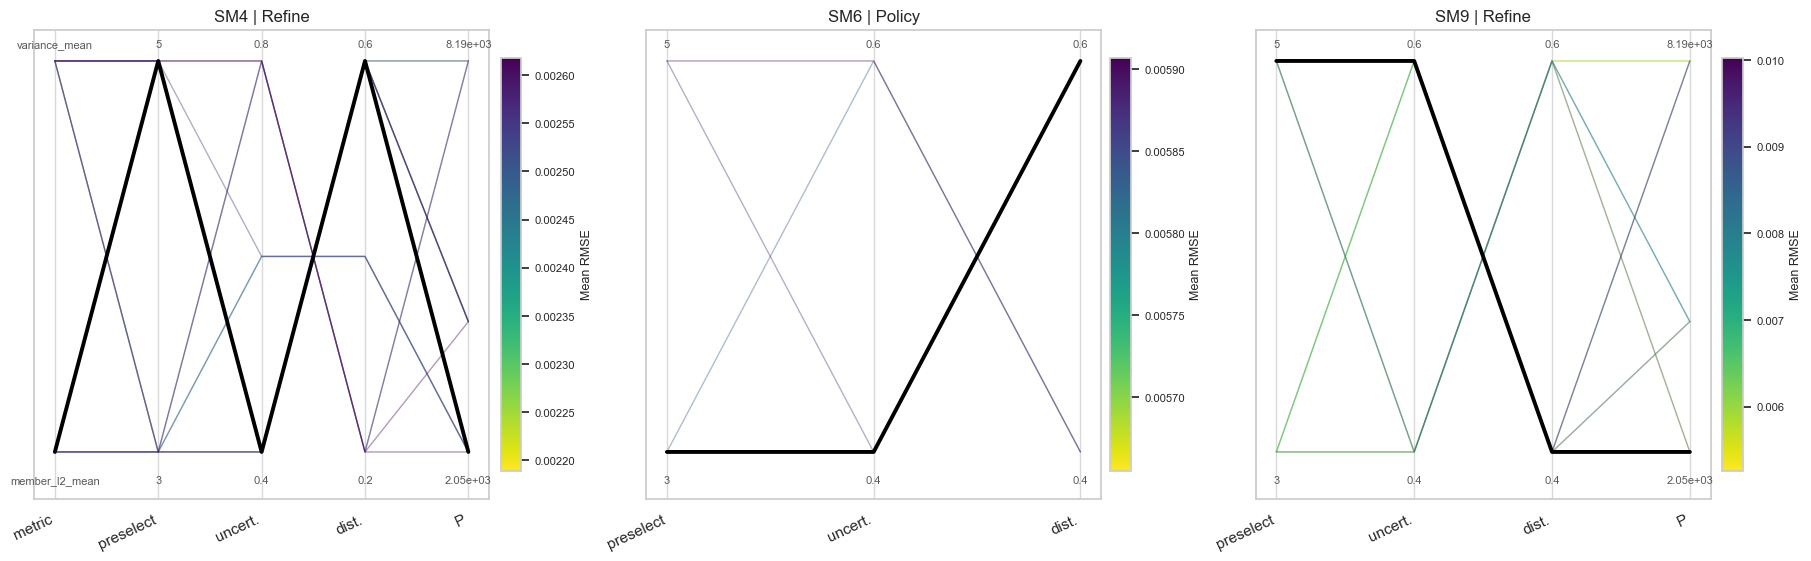

,model_flag,config_group_id,selected_stage,mean_final_eval_rmse,mean_objective_value,n_dataset_seeds,is_selected_winner,qbc_M,active.disagreement.metric,active.diversity.preselect_factor,active.diversity.uncertainty_weight,active.diversity.distance_weight,qbc_P
8,SM4,grp_24d963046b,Refine,0.002189,0.002189,3,True,5.0,member_l2_mean,5.0,0.4,0.6,2048
47,SM4,grp_e82dabc6e4,Refine,0.002309,0.002309,3,False,5.0,member_l2_mean,5.0,0.4,0.6,8192
39,SM4,grp_bafdd7d76d,Refine,0.002399,0.002399,3,False,5.0,member_l2_mean,3.0,0.4,0.6,4096
12,SM4,grp_305c8fd11a,Refine,0.002429,0.002429,3,False,5.0,member_l2_mean,5.0,0.4,0.6,4096
11,SM4,grp_2f155dc559,Refine,0.002453,0.002453,3,False,5.0,variance_mean,3.0,0.6,0.4,2048
45,SM4,grp_dd13467af9,Refine,0.002476,0.002476,3,False,5.0,variance_mean,3.0,0.8,0.2,8192
28,SM4,grp_8e23f0e9fb,Refine,0.002498,0.002498,3,False,5.0,variance_mean,5.0,0.4,0.6,2048
10,SM4,grp_29fb41b129,Refine,0.002502,0.002502,3,False,5.0,member_l2_mean,3.0,0.6,0.4,2048
56,SM6,grp_69c69f386d,Policy,0.005655,0.005655,2,True,5.0,member_l2_mean,3.0,0.4,0.6,2048
54,SM6,grp_2159097e09,Policy,0.005837,0.005837,2,False,5.0,member_l2_mean,3.0,0.6,0.4,2048


### Marker-Directed

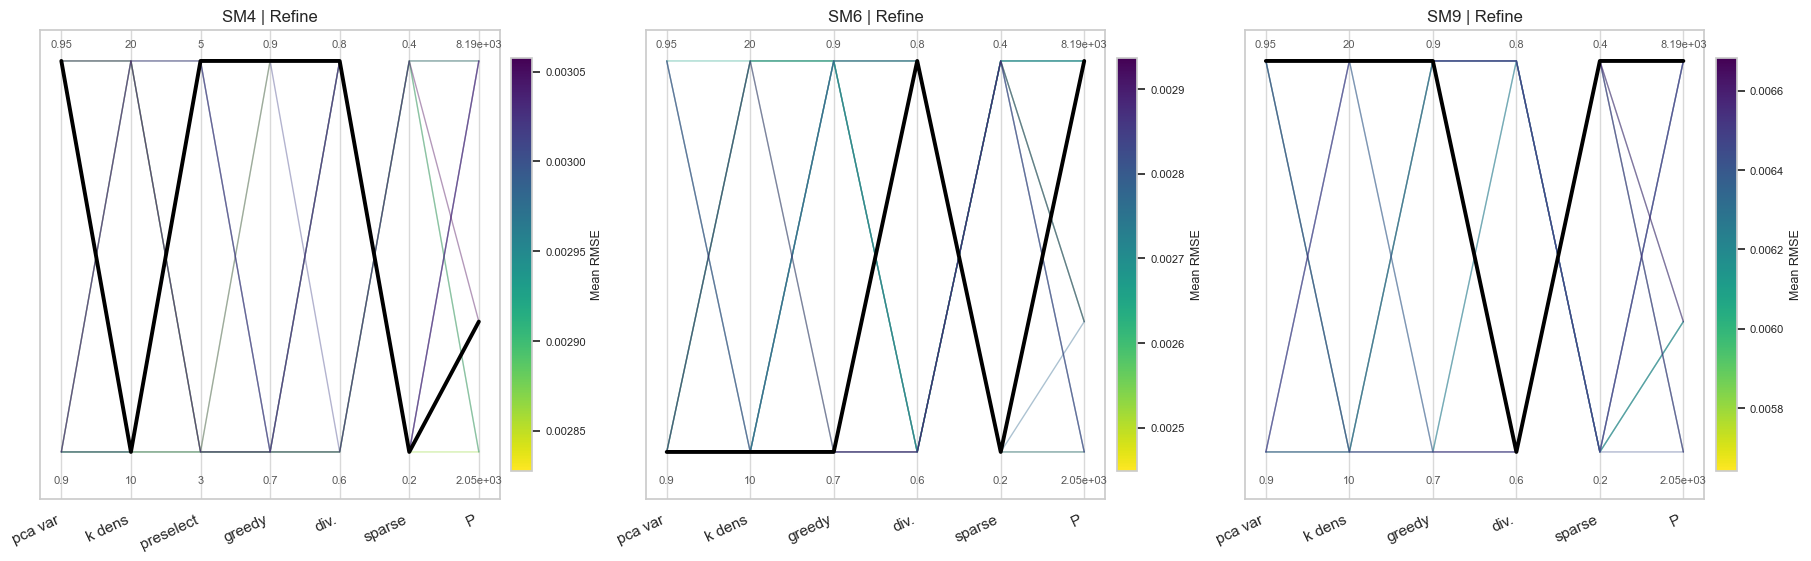

,model_flag,config_group_id,selected_stage,mean_final_eval_rmse,mean_objective_value,n_dataset_seeds,is_selected_winner,active.marker.pca_explained_variance,active.marker.k_density,active.marker.preselect_factor,active.marker.greedy_score_weight,active.marker.weights.diversity,active.marker.weights.sparsity,qbc_P
18,SM4,grp_3978bdabab,Refine,0.002828,0.002828,3,True,0.95,10.0,5.0,0.9,0.8,0.2,4096
19,SM4,grp_479a2d81dd,Refine,0.002858,0.002858,3,False,0.90,20.0,3.0,0.9,0.8,0.2,4096
62,SM4,grp_e1a98d3444,Refine,0.002864,0.002864,3,False,0.90,10.0,3.0,0.7,0.8,0.2,2048
60,SM4,grp_d83df45b32,Refine,0.002869,0.002869,3,False,0.95,20.0,3.0,0.7,0.6,0.4,2048
28,SM4,grp_6646f66adc,Refine,0.002888,0.002888,3,False,0.90,10.0,3.0,0.7,0.6,0.4,8192
23,SM4,grp_5ae965d253,Refine,0.002892,0.002892,3,False,0.90,10.0,5.0,0.9,0.8,0.2,4096
21,SM4,grp_5752297164,Refine,0.002956,0.002956,3,False,0.95,20.0,5.0,0.7,0.8,0.2,4096
42,SM4,grp_974c04e92c,Refine,0.002958,0.002958,3,False,0.90,20.0,3.0,0.7,0.6,0.4,2048
107,SM6,grp_b95ea5d678,Refine,0.002449,0.002449,2,True,0.90,10.0,3.0,0.7,0.8,0.2,8192
82,SM6,grp_374487313d,Refine,0.002581,0.002581,2,False,0.90,20.0,3.0,0.9,0.8,0.2,2048


### QBC Marker Hybrid

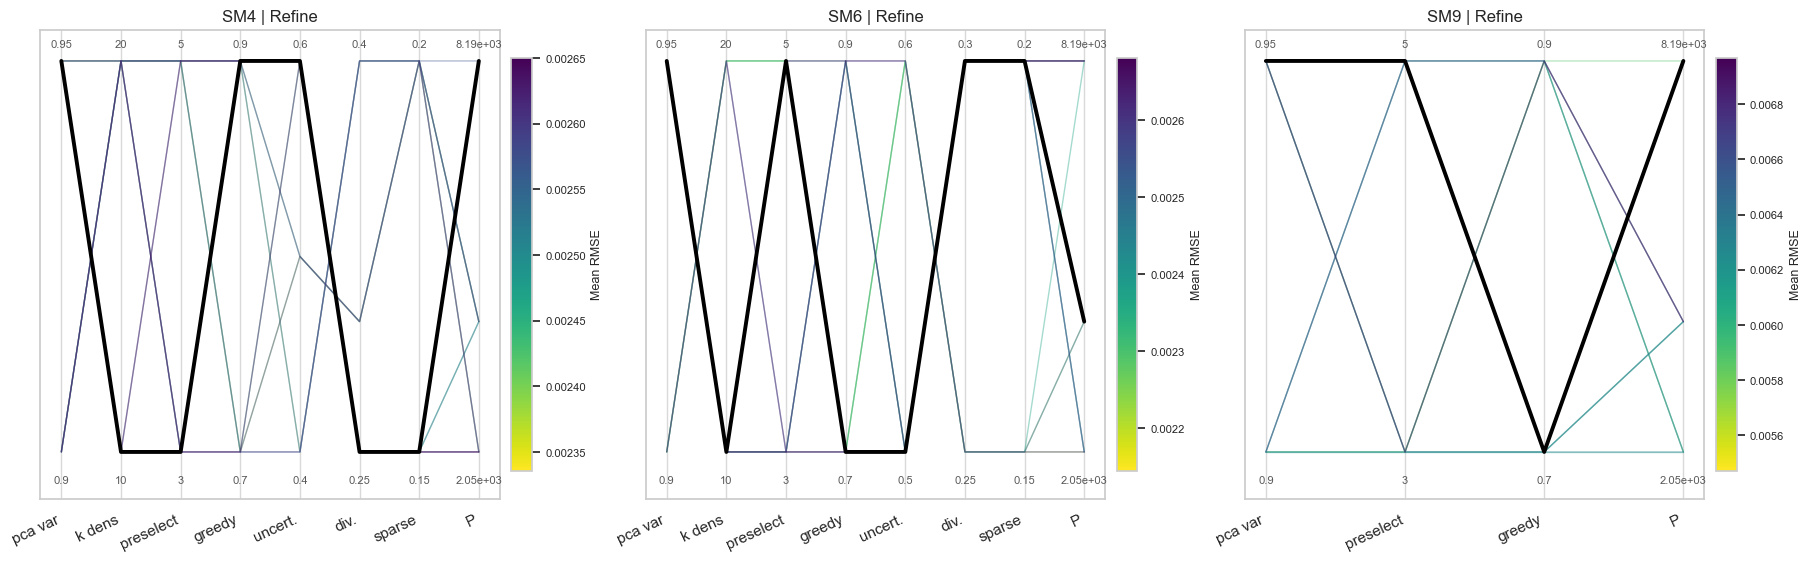

,model_flag,config_group_id,selected_stage,mean_final_eval_rmse,mean_objective_value,n_dataset_seeds,is_selected_winner,qbc_M,active.disagreement.metric,active.hybrid.pca_explained_variance,active.hybrid.k_density,active.hybrid.preselect_factor,active.hybrid.greedy_score_weight,active.hybrid.weights.uncertainty,active.hybrid.weights.diversity,active.hybrid.weights.sparsity,qbc_P
27,SM4,grp_8f4b6a6a94,Refine,0.002336,0.002336,3,True,5.0,member_l2_mean,0.95,10.0,3.0,0.9,0.6,0.25,0.15,8192
10,SM4,grp_4bb9df3fde,Refine,0.002402,0.002402,3,False,5.0,member_l2_mean,0.95,20.0,5.0,0.7,0.5,0.30,0.20,2048
8,SM4,grp_3674092583,Refine,0.002417,0.002417,3,False,5.0,member_l2_mean,0.90,20.0,5.0,0.9,0.4,0.40,0.20,4096
42,SM4,grp_e0a2052925,Refine,0.002448,0.002448,3,False,5.0,member_l2_mean,0.95,20.0,3.0,0.9,0.5,0.30,0.20,4096
38,SM4,grp_ceb35090fd,Refine,0.002459,0.002459,3,False,5.0,member_l2_mean,0.90,20.0,5.0,0.7,0.6,0.25,0.15,4096
45,SM4,grp_f34ac0a0a6,Refine,0.002536,0.002536,3,False,5.0,member_l2_mean,0.95,10.0,3.0,0.9,0.6,0.25,0.15,2048
34,SM4,grp_bf96c21f9c,Refine,0.002543,0.002543,3,False,5.0,member_l2_mean,0.95,10.0,3.0,0.9,0.6,0.25,0.15,4096
36,SM4,grp_cb5430e78d,Refine,0.002561,0.002561,3,False,5.0,member_l2_mean,0.95,10.0,5.0,0.9,0.6,0.25,0.15,8192
61,SM6,grp_a50e5e384b,Refine,0.002145,0.002145,2,True,5.0,member_l2_mean,0.95,10.0,5.0,0.7,0.5,0.30,0.20,4096
56,SM6,grp_67b71ba728,Refine,0.002251,0.002251,2,False,5.0,member_l2_mean,0.90,20.0,5.0,0.7,0.6,0.25,0.15,2048


In [16]:

METHOD_PARAMETER_COLUMNS = {
    'qbc_deep_ensemble': [
        'qbc_M',
        'active.disagreement.metric',
        'active.diversity.preselect_factor',
        'active.diversity.uncertainty_weight',
        'active.diversity.distance_weight',
        'qbc_P',
    ],
    'marker_directed': [
        'active.marker.pca_explained_variance',
        'active.marker.k_density',
        'active.marker.preselect_factor',
        'active.marker.greedy_score_weight',
        'active.marker.weights.diversity',
        'active.marker.weights.sparsity',
        'qbc_P',
    ],
    'qbc_marker_hybrid': [
        'qbc_M',
        'active.disagreement.metric',
        'active.hybrid.pca_explained_variance',
        'active.hybrid.k_density',
        'active.hybrid.preselect_factor',
        'active.hybrid.greedy_score_weight',
        'active.hybrid.weights.uncertainty',
        'active.hybrid.weights.diversity',
        'active.hybrid.weights.sparsity',
        'qbc_P',
    ],
}

AXIS_LABELS = {
    'qbc_M': 'M',
    'qbc_P': 'P',
    'active.disagreement.metric': 'metric',
    'active.diversity.preselect_factor': 'preselect',
    'active.diversity.uncertainty_weight': 'uncert.',
    'active.diversity.distance_weight': 'dist.',
    'active.marker.pca_explained_variance': 'pca var',
    'active.marker.k_density': 'k dens',
    'active.marker.preselect_factor': 'preselect',
    'active.marker.greedy_score_weight': 'greedy',
    'active.marker.weights.diversity': 'div.',
    'active.marker.weights.sparsity': 'sparse',
    'active.hybrid.pca_explained_variance': 'pca var',
    'active.hybrid.k_density': 'k dens',
    'active.hybrid.preselect_factor': 'preselect',
    'active.hybrid.greedy_score_weight': 'greedy',
    'active.hybrid.weights.uncertainty': 'uncert.',
    'active.hybrid.weights.diversity': 'div.',
    'active.hybrid.weights.sparsity': 'sparse',
}

selected_stage_lookup = final_winners[['workflow_id', 'method', 'model_flag', 'stage', 'winner_cfg_id']].rename(
    columns={'stage': 'selected_stage', 'winner_cfg_id': 'selected_winner_cfg_id'}
)

parallel_source = summary.merge(
    selected_stage_lookup,
    on=['workflow_id', 'method', 'model_flag'],
    how='inner',
)
parallel_source = parallel_source[parallel_source['stage'].astype(str) == parallel_source['selected_stage'].astype(str)].copy()


def first_non_null(series: pd.Series):
    series = series.dropna()
    if len(series) == 0:
        return np.nan
    return series.iloc[0]


def summarize_parallel_candidates(method: str) -> pd.DataFrame:
    method_df = parallel_source[parallel_source['method'] == method].copy()
    parameter_columns = METHOD_PARAMETER_COLUMNS[method]
    agg = {
        'final_eval_rmse': 'mean',
        'objective_value': 'mean',
        'dataset_seed': 'nunique',
        'selected_winner_cfg_id': first_non_null,
        'selected_stage': first_non_null,
    }
    for col in parameter_columns:
        agg[col] = first_non_null
    grouped = (
        method_df.groupby(['workflow_id', 'model_flag', 'method', 'config_group_id'], observed=True)
        .agg(agg)
        .reset_index()
        .rename(columns={
            'final_eval_rmse': 'mean_final_eval_rmse',
            'objective_value': 'mean_objective_value',
            'dataset_seed': 'n_dataset_seeds',
        })
    )
    grouped['is_selected_winner'] = grouped['config_group_id'] == grouped['selected_winner_cfg_id']
    return grouped


def normalize_axis(values: pd.Series):
    non_null = values.dropna()
    if non_null.empty:
        return values.astype(float), {'kind': 'empty', 'bottom': '', 'top': ''}

    if pd.api.types.is_numeric_dtype(non_null):
        non_null = non_null.astype(float)
        vmin = float(non_null.min())
        vmax = float(non_null.max())
        if np.isclose(vmin, vmax):
            scaled = pd.Series(0.5, index=values.index, dtype=float)
        else:
            scaled = (values.astype(float) - vmin) / (vmax - vmin)
        return scaled, {'kind': 'numeric', 'bottom': f'{vmin:.3g}', 'top': f'{vmax:.3g}'}

    categories = [str(v) for v in pd.Series(non_null.astype(str).unique()).sort_values().tolist()]
    if len(categories) == 1:
        mapping = {categories[0]: 0.5}
    else:
        mapping = {cat: idx / (len(categories) - 1) for idx, cat in enumerate(categories)}
    scaled = values.astype(str).map(mapping)
    return scaled, {'kind': 'categorical', 'bottom': categories[0], 'top': categories[-1], 'mapping': mapping}


for method in ADAPTIVE_METHODS:
    candidate_df = summarize_parallel_candidates(method)
    display(Markdown(f"### {METHOD_LABELS[method]}"))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True, sharey=True)
    axes = np.atleast_1d(axes)
    cmap = plt.cm.viridis_r

    for ax, model_flag in zip(axes, MODEL_ORDER):
        model_df = candidate_df[candidate_df['model_flag'].astype(str) == model_flag].copy()
        if model_df.empty:
            ax.set_axis_off()
            continue

        model_df = model_df.sort_values('mean_final_eval_rmse', ascending=True)
        winner_rows = model_df[model_df['is_selected_winner']]
        top_df = model_df.head(15)
        plot_df = (
            pd.concat([top_df, winner_rows], axis=0)
            .drop_duplicates('config_group_id')
            .sort_values('mean_final_eval_rmse', ascending=True)
            .copy()
        )

        parameter_columns = [
            col for col in METHOD_PARAMETER_COLUMNS[method]
            if col in plot_df.columns and plot_df[col].notna().any() and plot_df[col].nunique(dropna=True) > 1
        ]
        if not parameter_columns:
            ax.set_axis_off()
            continue

        model_rmse = plot_df['mean_final_eval_rmse'].dropna().to_numpy(dtype=float)
        rmse_min = float(np.min(model_rmse))
        rmse_max = float(np.max(model_rmse))
        if np.isclose(rmse_min, rmse_max):
            rmse_min -= 1e-9
            rmse_max += 1e-9
        color_norm = plt.Normalize(vmin=rmse_min, vmax=rmse_max)

        axis_meta = {}
        normalized = pd.DataFrame(index=plot_df.index)
        for col in parameter_columns:
            normalized[col], axis_meta[col] = normalize_axis(plot_df[col])

        x_positions = np.arange(len(parameter_columns), dtype=float)
        for xpos in x_positions:
            ax.axvline(x=xpos, color='0.85', linewidth=1, zorder=0)

        for _, row in plot_df.iterrows():
            y = normalized.loc[row.name, parameter_columns].to_numpy(dtype=float)
            line_color = 'black' if bool(row['is_selected_winner']) else cmap(color_norm(float(row['mean_final_eval_rmse'])))
            line_width = 2.8 if bool(row['is_selected_winner']) else 1.0
            alpha = 1.0 if bool(row['is_selected_winner']) else 0.4
            zorder = 3 if bool(row['is_selected_winner']) else 2
            ax.plot(x_positions, y, color=line_color, linewidth=line_width, alpha=alpha, zorder=zorder)

        ax.set_xticks(x_positions, [AXIS_LABELS.get(col, col.split('.')[-1]) for col in parameter_columns], rotation=25, ha='right')
        ax.set_ylim(-0.12, 1.08)
        ax.set_yticks([])
        selected_stage = str(model_df['selected_stage'].iloc[0])
        ax.set_title(f"{MODEL_LABELS[model_flag]} | {STAGE_LABELS.get(selected_stage, selected_stage.title())}")
        ax.grid(False)

        for xpos, col in zip(x_positions, parameter_columns):
            meta = axis_meta[col]
            ax.text(xpos, -0.06, meta['bottom'], ha='center', va='top', fontsize=8, color='0.35')
            ax.text(xpos, 1.03, meta['top'], ha='center', va='bottom', fontsize=8, color='0.35')

        sm = plt.cm.ScalarMappable(norm=color_norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, shrink=0.88, pad=0.02)
        cbar.set_label('Mean RMSE', fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    plt.show()

    method_table = candidate_df[[
        'model_flag', 'config_group_id', 'selected_stage', 'mean_final_eval_rmse', 'mean_objective_value', 'n_dataset_seeds', 'is_selected_winner'
    ] + METHOD_PARAMETER_COLUMNS[method]].copy()
    method_table['model_flag'] = method_table['model_flag'].map(MODEL_LABELS)
    method_table['selected_stage'] = method_table['selected_stage'].map(lambda s: STAGE_LABELS.get(str(s), str(s)))
    display(method_table.sort_values(['model_flag', 'mean_final_eval_rmse']).groupby('model_flag', group_keys=False).head(8))


## 8. Local Artifact And Telemetry Availability

In [17]:

path_columns = ['stage_root', 'run_manifest_path', 'history_path', 'dataset_manifest_path']
audit_rows = []
for column in path_columns:
    values = summary[column].dropna().astype(str)
    exists = values.map(lambda p: Path(p).exists())
    audit_rows.append({
        'column': column,
        'non_null_rows': len(values),
        'existing_rows': int(exists.sum()),
        'missing_rows': int((~exists).sum()),
        'coverage_pct': float(exists.mean() * 100.0) if len(values) else np.nan,
    })
artifact_audit = pd.DataFrame(audit_rows)
display(artifact_audit)

print('Unique stage roots referenced in refined summary:', summary['stage_root'].nunique())
print('Unique workflow ids referenced in refined summary:', summary['workflow_id'].nunique())

if (artifact_audit['existing_rows'] == 0).all():
    display(Markdown(
        '**Interpretation.** The canonical summary tables are present locally, but the linked per-run HPO artifacts are not. '        'This is enough for workflow-level analysis, but not for per-round telemetry, learning-curve, or candidate-acquisition diagnostics.'
    ))


,column,non_null_rows,existing_rows,missing_rows,coverage_pct
0,stage_root,1347,0,1347,0.0
1,run_manifest_path,1347,0,1347,0.0
2,history_path,1347,0,1347,0.0
3,dataset_manifest_path,1347,0,1347,0.0


Unique stage roots referenced in refined summary: 26
Unique workflow ids referenced in refined summary: 9


**Interpretation.** The canonical summary tables are present locally, but the linked per-run HPO artifacts are not. This is enough for workflow-level analysis, but not for per-round telemetry, learning-curve, or candidate-acquisition diagnostics.


## 9. SM9 Winner Telemetry

The previous artifact audit checked whether the original remote paths referenced by `hpo_summary.csv` are available locally. In addition to that remote-path audit, we now load the pushed local winner bundle in `results/hpo/winner_telemetry_sm9` and analyze the round-wise telemetry for the selected `SM9` winner configurations.


,method_label,cfg_id,dataset_seed,budget,n_rounds,final_eval_rmse,initial_eval_rmse,mean_round_seconds,total_round_seconds,mean_candidate_simulation_seconds,mean_acquisition_seconds,absolute_rmse_improvement,rmse_improvement_per_100s
0,Marker-Directed,cfg_00047_942e877de4,s01,b4096,31,0.005758,0.005758,22.627335,701.447391,16.654024,3.576793,0.000000,0.000000
1,Marker-Directed,cfg_00095_e16fb04c46,s02,b4096,31,0.005525,0.005525,22.958565,711.715524,16.933104,3.588991,0.000000,0.000000
2,QBC Deep Ensemble,cfg_00009_d61b021ca3,s01,b4096,31,0.004989,0.486165,103.788258,3217.436002,0.000000,2.204269,0.481175,0.014955
3,QBC Deep Ensemble,cfg_00021_e5d4b19d6f,s02,b4096,31,0.005536,0.485703,79.893905,2476.711062,0.000000,2.066828,0.480166,0.019387
4,QBC Marker Hybrid,cfg_00020_31fca29af1,s01,b4096,31,0.005770,0.486165,86.761908,2689.619154,0.000000,11.841177,0.480395,0.017861
5,QBC Marker Hybrid,cfg_00044_adf2153cda,s02,b4096,31,0.005173,0.485703,98.416847,3050.922269,0.000000,12.526552,0.480530,0.015750


,method_label,budget,n_runs,dataset_seeds,mean_initial_eval_rmse,mean_final_eval_rmse,mean_absolute_rmse_improvement,mean_rmse_improvement_per_100s,std_final_eval_rmse,mean_total_round_seconds,mean_round_seconds
0,Marker-Directed,b4096,2,"s01, s02",0.005642,0.005642,0.000000,0.000000,0.000164,706.581458,22.792950
1,QBC Deep Ensemble,b4096,2,"s01, s02",0.485934,0.005263,0.480671,0.017171,0.000387,2847.073532,91.841082
2,QBC Marker Hybrid,b4096,2,"s01, s02",0.485934,0.005471,0.480462,0.016806,0.000422,2870.270712,92.589378


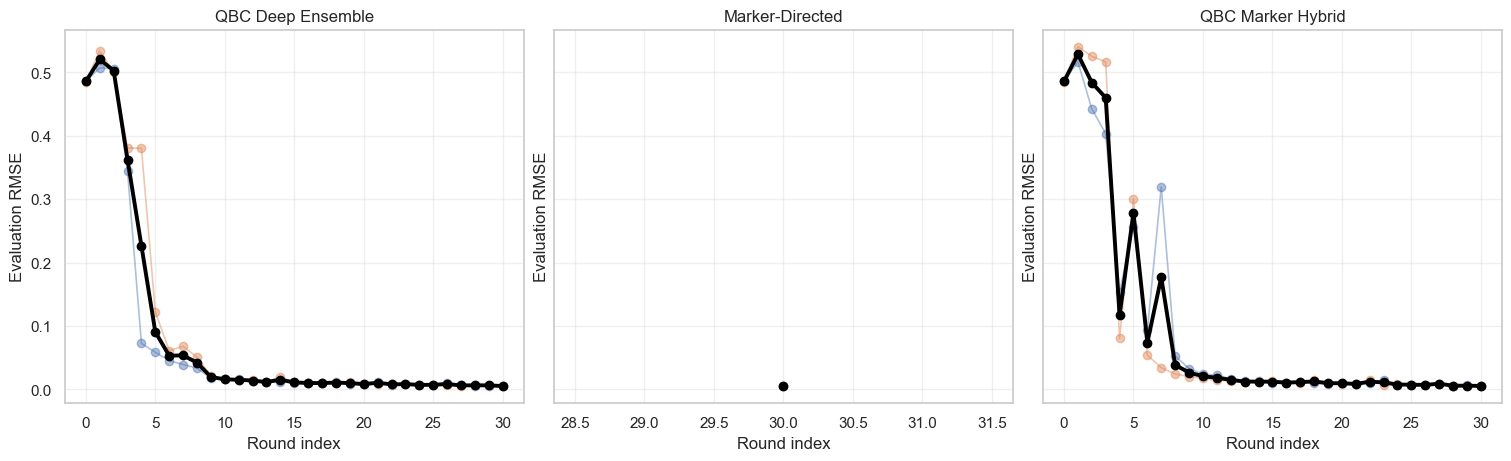

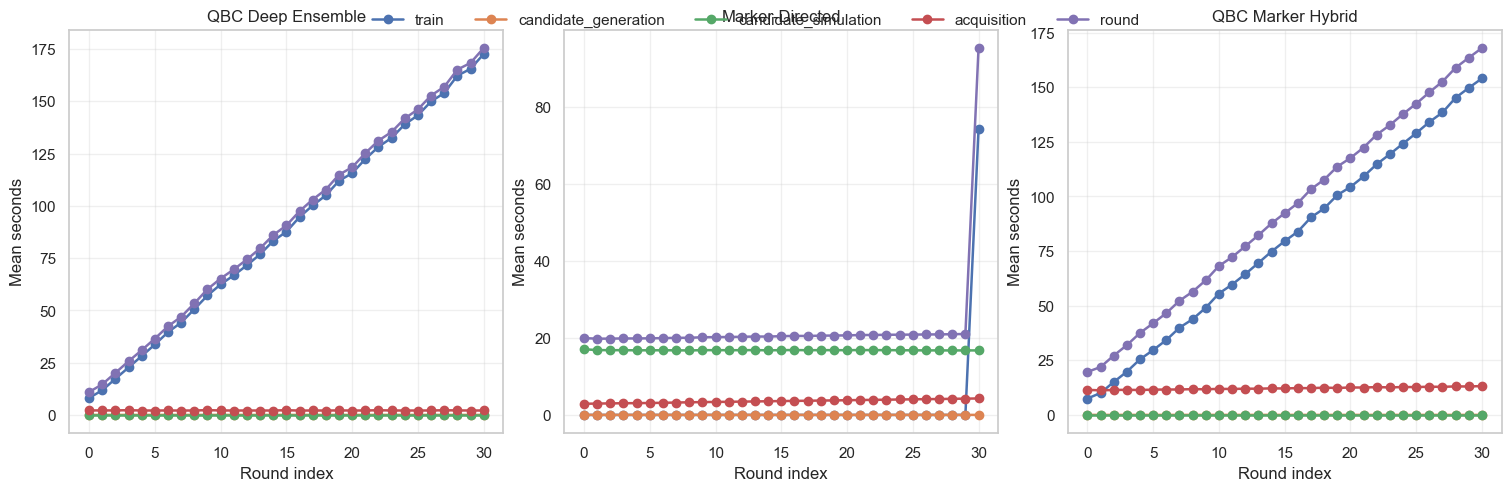

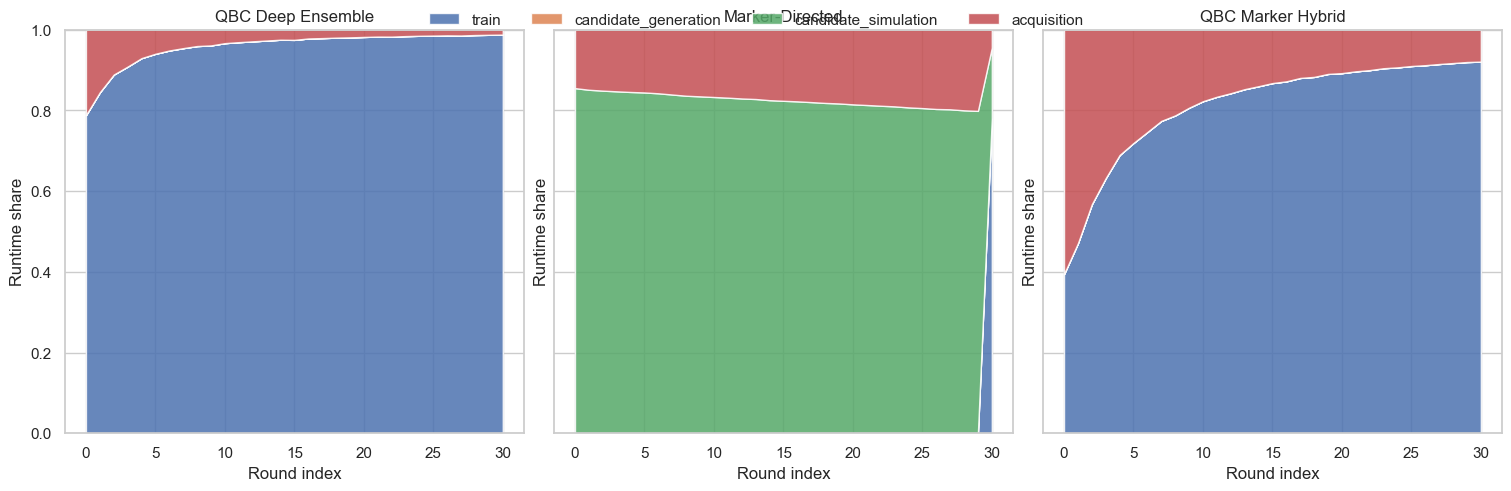

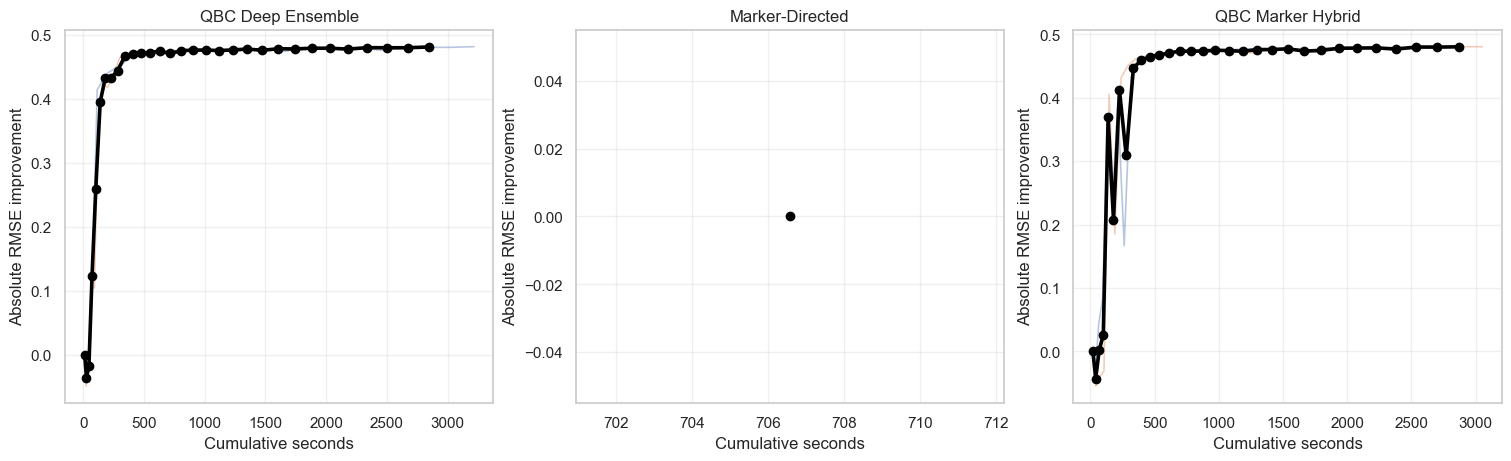

,method_label,round_idx,mean_cumulative_seconds,mean_absolute_improvement,mean_improvement_per_100s
28,Marker-Directed,28,590.365488,NaN,NaN
29,Marker-Directed,29,611.366341,NaN,NaN
30,Marker-Directed,30,706.581458,0.000000,0.000000
59,QBC Deep Ensemble,28,2503.210719,0.479442,0.019477
60,QBC Deep Ensemble,29,2671.572422,0.479488,0.018254
61,QBC Deep Ensemble,30,2847.073532,0.480671,0.017171
90,QBC Marker Hybrid,28,2538.810993,0.480125,0.018986
91,QBC Marker Hybrid,29,2702.313820,0.480005,0.017832
92,QBC Marker Hybrid,30,2870.270712,0.480462,0.016806


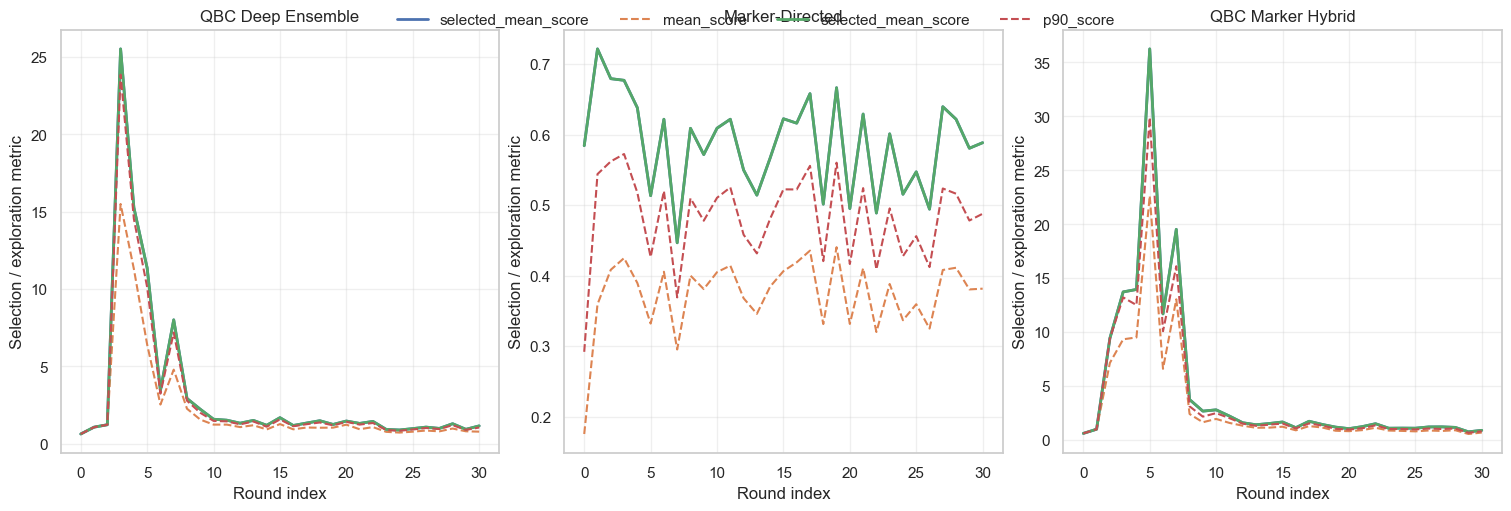

,method_label,n_runs,mean_final_eval_rmse,std_final_eval_rmse,min_final_eval_rmse,max_final_eval_rmse,mean_total_round_seconds,std_total_round_seconds
0,Marker-Directed,2,0.005642,0.000164,0.005525,0.005758,706.581458,7.260667
1,QBC Deep Ensemble,2,0.005263,0.000387,0.004989,0.005536,2847.073532,523.771628
2,QBC Marker Hybrid,2,0.005471,0.000422,0.005173,0.005770,2870.270712,255.479883


In [19]:

WINNER_TELEMETRY_ROOT = HPO_ROOT / 'winner_telemetry_sm9'
telemetry_paths = sorted(WINNER_TELEMETRY_ROOT.glob('*/*/runs/*/telemetry/round_telemetry.csv'))

import json

telemetry_records = []
for telemetry_path in telemetry_paths:
    workflow_dir = telemetry_path.parents[4].name
    stage = telemetry_path.parents[3].name
    cfg_id = telemetry_path.parents[1].name
    method_key = workflow_dir.replace('_sm_avr_gov_v1', '')

    tele_df = pd.read_csv(telemetry_path)
    hpo_row_path = telemetry_path.parents[1] / 'hpo_row.json'
    dataset_manifest_path = telemetry_path.parents[1] / 'dataset_manifest.json'
    history_path = telemetry_path.parents[1] / 'qbc' / 'history.jsonl'

    dataset_seed = None
    budget = None
    if hpo_row_path.exists():
        hpo_row = json.loads(hpo_row_path.read_text())
        dataset_seed = hpo_row.get('dataset_seed') or hpo_row.get('seed')
        budget = hpo_row.get('budget')

    if dataset_seed is None or budget is None:
        manifest = json.loads(dataset_manifest_path.read_text())
        experiment = manifest.get('experiment', {}) if isinstance(manifest.get('experiment', {}), dict) else {}
        dataset_seed = dataset_seed or experiment.get('dataset_seed')
        budget = budget or experiment.get('budget')

    if history_path.exists():
        history_rows = []
        with history_path.open() as f:
            for line in f:
                history_rows.append(json.loads(line))
        history_df = pd.DataFrame(history_rows)
        merge_cols = [c for c in ['round_idx', 'eval_rmse', 'eval_mse'] if c in history_df.columns]
        if 'round_idx' in merge_cols:
            history_eval = history_df[merge_cols].copy().rename(columns={
                'eval_rmse': 'history_eval_rmse',
                'eval_mse': 'history_eval_mse',
            })
            tele_df = tele_df.merge(history_eval, on='round_idx', how='left')
            if 'eval_rmse' in tele_df.columns and 'history_eval_rmse' in tele_df.columns:
                tele_df['eval_rmse'] = tele_df['eval_rmse'].fillna(tele_df['history_eval_rmse'])
            if 'eval_mse' in tele_df.columns and 'history_eval_mse' in tele_df.columns:
                tele_df['eval_mse'] = tele_df['eval_mse'].fillna(tele_df['history_eval_mse'])

    tele_df['workflow_dir'] = workflow_dir
    tele_df['stage'] = stage
    tele_df['cfg_id'] = cfg_id
    tele_df['method'] = method_key
    tele_df['method_label'] = METHOD_LABELS.get(method_key, method_key)
    tele_df['model_label'] = 'SM9'
    tele_df['dataset_seed'] = dataset_seed
    tele_df['budget'] = budget
    telemetry_records.append(tele_df)

winner_telemetry_df = pd.concat(telemetry_records, ignore_index=True) if telemetry_records else pd.DataFrame()
winner_telemetry_df = winner_telemetry_df.sort_values(['method', 'dataset_seed', 'round_idx']).reset_index(drop=True)

telemetry_run_summary = (
    winner_telemetry_df.groupby(['method_label', 'cfg_id', 'dataset_seed', 'budget'], observed=True)
    .agg(
        n_rounds=('round_idx', 'max'),
        final_eval_rmse=('eval_rmse', 'last'),
        initial_eval_rmse=('eval_rmse', 'first'),
        mean_round_seconds=('round_seconds', 'mean'),
        total_round_seconds=('round_seconds', 'sum'),
        mean_candidate_simulation_seconds=('candidate_simulation_seconds', 'mean'),
        mean_acquisition_seconds=('acquisition_seconds', 'mean'),
    )
    .reset_index()
)
telemetry_run_summary['n_rounds'] = telemetry_run_summary['n_rounds'] + 1
telemetry_run_summary['absolute_rmse_improvement'] = telemetry_run_summary['initial_eval_rmse'] - telemetry_run_summary['final_eval_rmse']
telemetry_run_summary['rmse_improvement_per_100s'] = 100.0 * telemetry_run_summary['absolute_rmse_improvement'] / telemetry_run_summary['total_round_seconds']

display(telemetry_run_summary.sort_values(['method_label', 'dataset_seed']))

telemetry_method_summary = (
    telemetry_run_summary.groupby(['method_label', 'budget'], observed=True)
    .agg(
        n_runs=('cfg_id', 'size'),
        dataset_seeds=('dataset_seed', lambda s: ', '.join(sorted(s.astype(str).unique()))),
        mean_initial_eval_rmse=('initial_eval_rmse', 'mean'),
        mean_final_eval_rmse=('final_eval_rmse', 'mean'),
        mean_absolute_rmse_improvement=('absolute_rmse_improvement', 'mean'),
        mean_rmse_improvement_per_100s=('rmse_improvement_per_100s', 'mean'),
        std_final_eval_rmse=('final_eval_rmse', 'std'),
        mean_total_round_seconds=('total_round_seconds', 'mean'),
        mean_round_seconds=('mean_round_seconds', 'mean'),
    )
    .reset_index()
)
display(telemetry_method_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, method in zip(axes, ADAPTIVE_METHODS):
    sub = winner_telemetry_df[winner_telemetry_df['method'] == method].copy()
    if sub.empty:
        ax.set_axis_off()
        continue
    for dataset_seed, seed_df in sub.groupby('dataset_seed', observed=True):
        seed_df = seed_df.sort_values('round_idx')
        ax.plot(seed_df['round_idx'], seed_df['eval_rmse'], marker='o', linewidth=1.2, alpha=0.45, label=str(dataset_seed))
    mean_df = (
        sub.groupby('round_idx', observed=True)
        .agg(eval_rmse=('eval_rmse', 'mean'))
        .reset_index()
        .sort_values('round_idx')
    )
    ax.plot(mean_df['round_idx'], mean_df['eval_rmse'], color='black', linewidth=2.8, marker='o', label='mean')
    ax.set_title(METHOD_LABELS[method])
    ax.set_xlabel('Round index')
    ax.set_ylabel('Evaluation RMSE')
    ax.grid(alpha=0.3)
plt.show()

runtime_components = [
    'train_seconds',
    'candidate_generation_seconds',
    'candidate_simulation_seconds',
    'acquisition_seconds',
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True, sharey=False)
axes = np.atleast_1d(axes)
for ax, method in zip(axes, ADAPTIVE_METHODS):
    sub = winner_telemetry_df[winner_telemetry_df['method'] == method].copy()
    if sub.empty:
        ax.set_axis_off()
        continue
    mean_runtime = (
        sub.groupby('round_idx', observed=True)[runtime_components + ['round_seconds']]
        .mean()
        .reset_index()
        .sort_values('round_idx')
    )
    for component in runtime_components + ['round_seconds']:
        ax.plot(mean_runtime['round_idx'], mean_runtime[component], marker='o', linewidth=1.8, label=component.replace('_seconds', ''))
    ax.set_title(METHOD_LABELS[method])
    ax.set_xlabel('Round index')
    ax.set_ylabel('Mean seconds')
    ax.grid(alpha=0.3)
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, frameon=False)
plt.show()

runtime_share_df = winner_telemetry_df.copy()
runtime_share_totals = runtime_share_df[runtime_components].sum(axis=1).replace(0.0, np.nan)
for component in runtime_components:
    runtime_share_df[f'{component}_share'] = runtime_share_df[component] / runtime_share_totals

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True, sharey=True)
axes = np.atleast_1d(axes)
share_cols = [f'{component}_share' for component in runtime_components]
share_labels = [component.replace('_seconds', '') for component in runtime_components]
for ax, method in zip(axes, ADAPTIVE_METHODS):
    sub = runtime_share_df[runtime_share_df['method'] == method].copy()
    if sub.empty:
        ax.set_axis_off()
        continue
    mean_share = (
        sub.groupby('round_idx', observed=True)[share_cols]
        .mean()
        .reset_index()
        .sort_values('round_idx')
    )
    ax.stackplot(mean_share['round_idx'], [mean_share[c].fillna(0.0) for c in share_cols], labels=share_labels, alpha=0.85)
    ax.set_title(METHOD_LABELS[method])
    ax.set_xlabel('Round index')
    ax.set_ylabel('Runtime share')
    ax.set_ylim(0, 1)
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
plt.show()

improvement_df = winner_telemetry_df.copy()
improvement_df['cumulative_seconds'] = improvement_df.groupby(['method', 'dataset_seed'], observed=True)['round_seconds'].cumsum()
improvement_df['initial_eval_rmse'] = improvement_df.groupby(['method', 'dataset_seed'], observed=True)['eval_rmse'].transform('first')
improvement_df['absolute_improvement'] = improvement_df['initial_eval_rmse'] - improvement_df['eval_rmse']
improvement_df['improvement_per_100s'] = 100.0 * improvement_df['absolute_improvement'] / improvement_df['cumulative_seconds'].replace(0.0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True, sharey=False)
axes = np.atleast_1d(axes)
for ax, method in zip(axes, ADAPTIVE_METHODS):
    sub = improvement_df[improvement_df['method'] == method].copy()
    if sub.empty:
        ax.set_axis_off()
        continue
    for dataset_seed, seed_df in sub.groupby('dataset_seed', observed=True):
        seed_df = seed_df.sort_values('cumulative_seconds')
        ax.plot(seed_df['cumulative_seconds'], seed_df['absolute_improvement'], alpha=0.4, linewidth=1.2)
    mean_df = (
        sub.groupby('round_idx', observed=True)
        .agg(
            cumulative_seconds=('cumulative_seconds', 'mean'),
            absolute_improvement=('absolute_improvement', 'mean'),
            improvement_per_100s=('improvement_per_100s', 'mean'),
        )
        .reset_index()
        .sort_values('round_idx')
    )
    ax.plot(mean_df['cumulative_seconds'], mean_df['absolute_improvement'], color='black', linewidth=2.6, marker='o')
    ax.set_title(METHOD_LABELS[method])
    ax.set_xlabel('Cumulative seconds')
    ax.set_ylabel('Absolute RMSE improvement')
    ax.grid(alpha=0.3)
plt.show()

efficiency_summary = (
    improvement_df.groupby(['method_label', 'round_idx'], observed=True)
    .agg(
        mean_cumulative_seconds=('cumulative_seconds', 'mean'),
        mean_absolute_improvement=('absolute_improvement', 'mean'),
        mean_improvement_per_100s=('improvement_per_100s', 'mean'),
    )
    .reset_index()
)
display(efficiency_summary.groupby('method_label', group_keys=False).tail(3))

selection_metric_candidates = [
    ('selected_mean_score', 'mean_score'),
    ('selected_mean_score', 'p90_score'),
    ('mean_disagreement', None),
    ('mean_selected_to_train_distance', None),
    ('mean_selected_marker_diversity', None),
    ('mean_selected_marker_sparsity', None),
    ('mean_selected_hybrid_uncertainty', None),
    ('mean_selected_hybrid_diversity', None),
    ('mean_selected_hybrid_sparsity', None),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.0), constrained_layout=True, sharey=False)
axes = np.atleast_1d(axes)
for ax, method in zip(axes, ADAPTIVE_METHODS):
    sub = winner_telemetry_df[winner_telemetry_df['method'] == method].copy()
    if sub.empty:
        ax.set_axis_off()
        continue
    mean_sub = sub.groupby('round_idx', observed=True).mean(numeric_only=True).reset_index()
    plotted = 0
    for primary, secondary in selection_metric_candidates:
        if primary in mean_sub.columns and mean_sub[primary].notna().any():
            ax.plot(mean_sub['round_idx'], mean_sub[primary], linewidth=2.0, label=primary)
            plotted += 1
            if secondary and secondary in mean_sub.columns and mean_sub[secondary].notna().any():
                ax.plot(mean_sub['round_idx'], mean_sub[secondary], linewidth=1.5, linestyle='--', label=secondary)
                plotted += 1
        if plotted >= 4:
            break
    ax.set_title(METHOD_LABELS[method])
    ax.set_xlabel('Round index')
    ax.set_ylabel('Selection / exploration metric')
    ax.grid(alpha=0.3)
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
plt.show()

seed_stability_summary = (
    telemetry_run_summary.groupby('method_label', observed=True)
    .agg(
        n_runs=('cfg_id', 'size'),
        mean_final_eval_rmse=('final_eval_rmse', 'mean'),
        std_final_eval_rmse=('final_eval_rmse', 'std'),
        min_final_eval_rmse=('final_eval_rmse', 'min'),
        max_final_eval_rmse=('final_eval_rmse', 'max'),
        mean_total_round_seconds=('total_round_seconds', 'mean'),
        std_total_round_seconds=('total_round_seconds', 'std'),
    )
    .reset_index()
)
display(seed_stability_summary)



## 10. Practical Conclusion

The refined HPO results are already analyzable from the canonical CSV exports alone. The notebook above therefore focuses on:

- workflow coverage in the refined `smoke -> policy -> refine` pipeline,
- winner summaries by model and adaptive method,
- selected end-state hyperparameters, and
- a concrete audit of whether the linked telemetry artifacts are available locally.

If deeper HPO telemetry analysis is needed later, the most useful additional artifacts to push are the per-stage workflow directories referenced by `stage_root`, including:

- `runs/*/run_manifest.json`
- `runs/*/qbc/history.jsonl`
- `runs/*/telemetry/round_telemetry.csv`
- `runs/*/dataset_manifest.json`
- stage-level ranking files such as `stage_results.csv`, `stage_ranked.csv`, `stage_shortlist.json`, and `stage_winner.json`
